In [1]:
import numpy as np
import matplotlib.pyplot as plt
import function as fn
from importlib import reload
from scipy import optimize
import h5py
reload(fn) 

<module 'function' from '/home/jenish/SS26/HMC-Schwinger/plot/function.py'>

In [2]:
file_4 = "../data/hmc_simulation.h5"
save_path = "../latex/Fig/"

f = h5py.File(file_4,"r")


In [3]:
data = []
for i in f["first_sim"]:
    temp = f["first_sim"][i]
    data.append(temp)

data = np.array(data)
f.close()

In [4]:
running_mean = fn.running_mean(data)


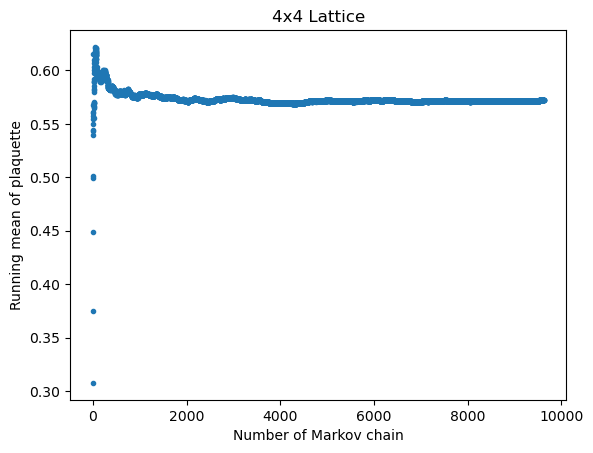

In [5]:
plt.plot(running_mean,".")
plt.xlabel("Number of Markov chain")
plt.ylabel("Running mean of plaquette")
plt.title("4x4 Lattice")
plt.savefig(save_path+"runnig_mean_4x4.png")

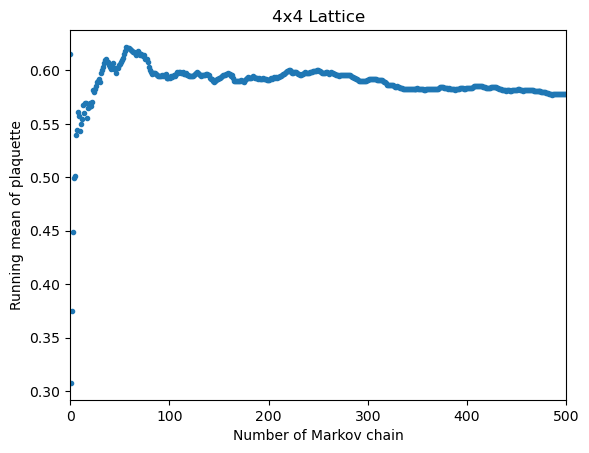

In [6]:
plt.plot(running_mean,".")
plt.xlim(0,500)
plt.xlabel("Number of Markov chain")
plt.ylabel("Running mean of plaquette")
plt.title("4x4 Lattice")
plt.savefig(save_path+"runnig_mean_4x4_zoomed.png")

data = data[500:,:,:,:]

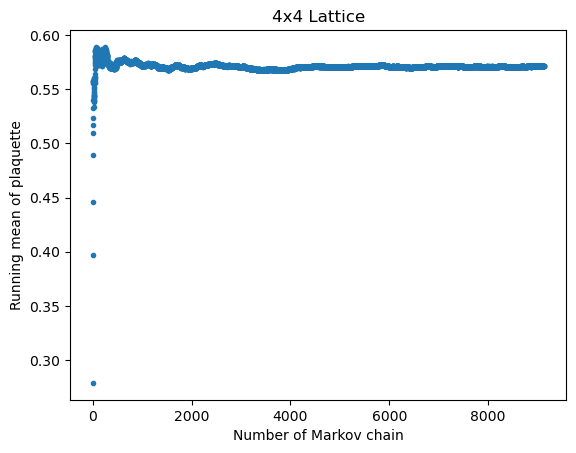

In [7]:

running_mean = fn.running_mean(data)
plt.plot(running_mean,".")
plt.xlabel("Number of Markov chain")
plt.ylabel("Running mean of plaquette")
plt.title("4x4 Lattice")
plt.savefig(save_path+"runnig_mean_4x4_after_burnin.png")

In [8]:
L = data.shape[0]
T_Q = np.zeros(L)

for i in range(L):
    T_Q[i] = fn.topological_charge(data[i,:,:,:])

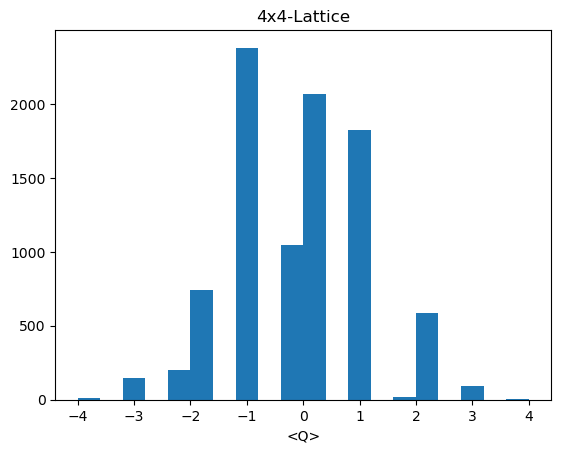

In [9]:

plt.hist(T_Q,20)
plt.title("4x4-Lattice")
plt.xlabel("<Q>")
plt.savefig(save_path+"Q_4.png")
plt.show()

In [10]:
T = 1
L = 4
R = np.linspace(1,L,L,dtype=np.int64)
N = data.shape[0]
W_4 = np.zeros((N,L))
for l in range(N):
    for i in R:
       W_4[l,i-1] = fn.wilson_loop(data[l],i,T)


In [11]:
file_5 = "../data/hmc_sim_5x5Lattice.h5"

f = h5py.File(file_5,"r")

In [12]:
data_5_L = []
for i in f["first_sim"]:
    temp = f["first_sim"][i]
    data_5_L.append(temp)

data_5_L = np.array(data_5_L)
f.close()

In [13]:
running_mean_5_L = fn.running_mean(data_5_L)


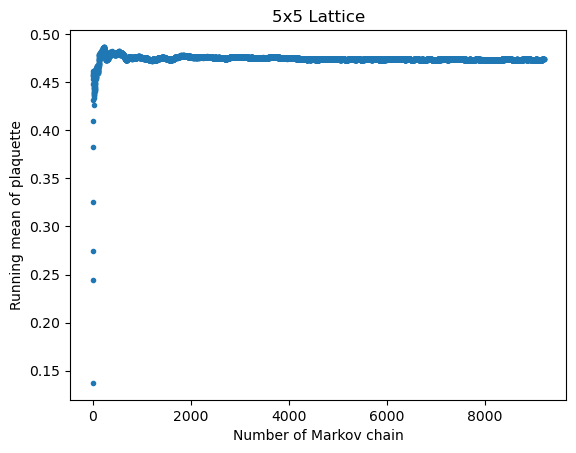

In [14]:
plt.plot(running_mean_5_L,".")
plt.xlabel("Number of Markov chain")
plt.ylabel("Running mean of plaquette")
plt.title("5x5 Lattice")
plt.savefig(save_path+"runnig_mean_5x5.png")

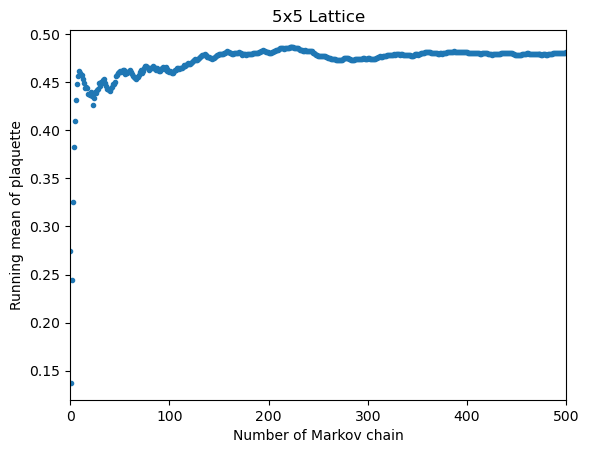

In [15]:
plt.plot(running_mean_5_L,".")
plt.xlim(0,500)
plt.xlabel("Number of Markov chain")
plt.ylabel("Running mean of plaquette")
plt.title("5x5 Lattice")
plt.savefig(save_path+"runnig_mean_5x5_zoomed.png")

data_5_L = data_5_L[500:,:,:,:]

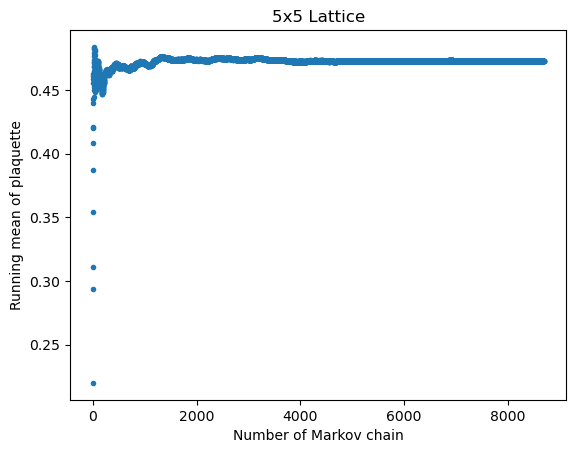

In [16]:
running_mean_5_L = fn.running_mean(data_5_L)
plt.plot(running_mean_5_L,".")
plt.xlabel("Number of Markov chain")
plt.ylabel("Running mean of plaquette")
plt.title("5x5 Lattice")
plt.savefig(save_path+"runnig_mean_5x5_after_burnin.png")

In [17]:
L = data_5_L.shape[0]
T_Q_5_L = np.zeros(L)

for i in range(L):
    T_Q_5_L[i] = fn.topological_charge(data_5_L[i,:,:,:])

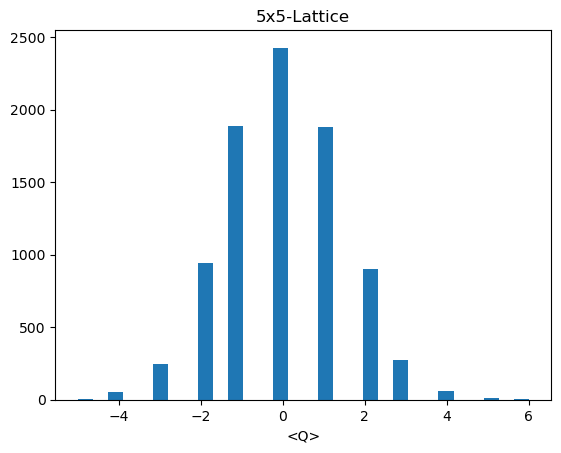

In [18]:
plt.hist(T_Q_5_L,30)
plt.title("5x5-Lattice")
plt.xlabel("<Q>")
plt.savefig(save_path+"Q_5.png")
plt.show()

In [19]:
L = 5 
R = np.linspace(1,L,L,dtype=np.int64)
N = data_5_L.shape[0]
W_5 = np.zeros((N,L))
for l in range(N):
    for i in R:
       W_5[l,i-1] = fn.wilson_loop(data_5_L[l],i,T)

In [20]:
file_6 = "../data/hmc_sim_6x6Lattice.h5"

f = h5py.File(file_6,"r")
data_6_L = []
for i in f["first_sim"]:
    temp = f["first_sim"][i]
    data_6_L.append(temp)

data_6_L = np.array(data_6_L)
f.close()

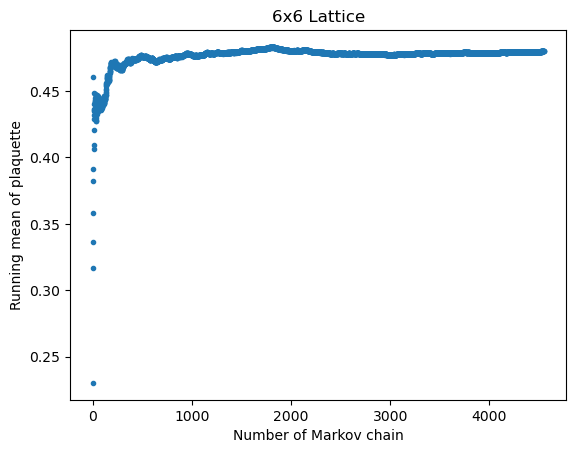

In [21]:
running_mean_6_L = fn.running_mean(data_6_L)
plt.plot(running_mean_6_L,".")
plt.xlabel("Number of Markov chain")
plt.ylabel("Running mean of plaquette")
plt.title("6x6 Lattice")
plt.savefig(save_path+"runnig_mean_6x6.png")

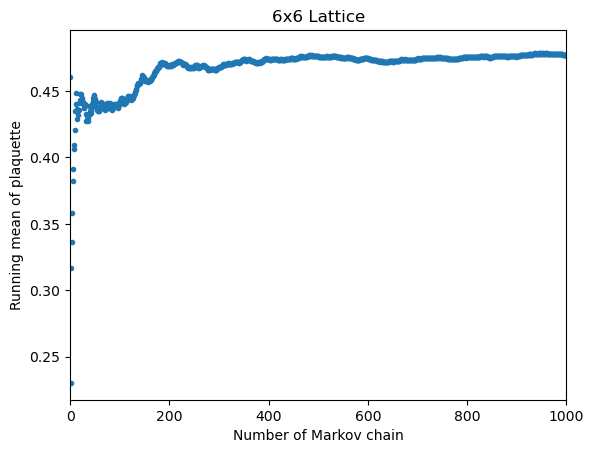

In [22]:
plt.plot(running_mean_6_L,".")
plt.xlim(0,1000)
plt.xlabel("Number of Markov chain")
plt.ylabel("Running mean of plaquette")
plt.title("6x6 Lattice")
plt.savefig(save_path+"runnig_mean_6x6_zoomed.png")

data_6_L = data_6_L[200:,:,:,:]

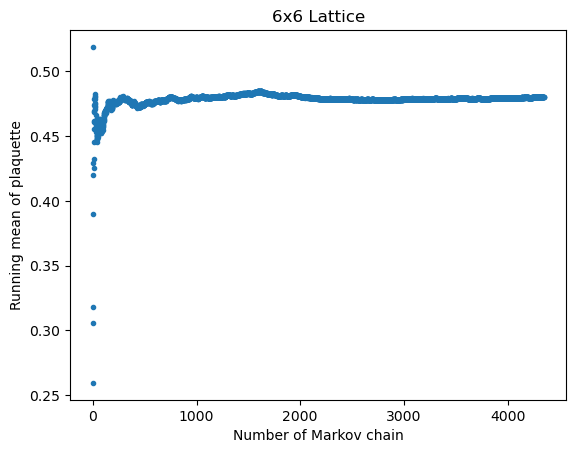

In [23]:
running_mean_6_L = fn.running_mean(data_6_L)
plt.plot(running_mean_6_L,".")
plt.xlabel("Number of Markov chain")
plt.ylabel("Running mean of plaquette")
plt.title("6x6 Lattice")
plt.savefig(save_path+"runnig_mean_6x6_after_burnin.png")

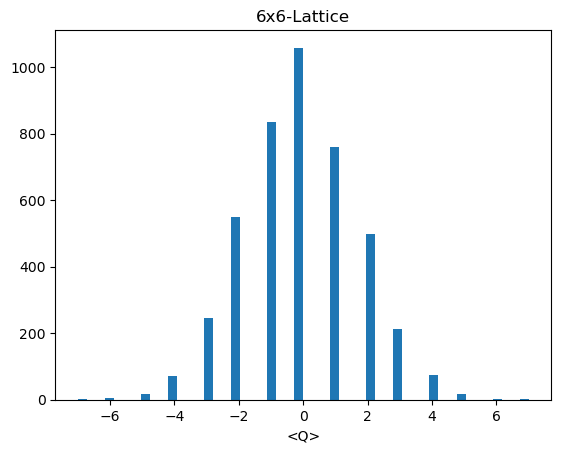

In [24]:
L = data_6_L.shape[0]
T_Q_6_L = np.zeros(L)

for i in range(L):
    T_Q_6_L[i] = fn.topological_charge(data_6_L[i,:,:,:])

plt.hist(T_Q_6_L,50)
plt.title("6x6-Lattice")
plt.xlabel("<Q>")
plt.savefig(save_path+"Q_6.png")
plt.show()

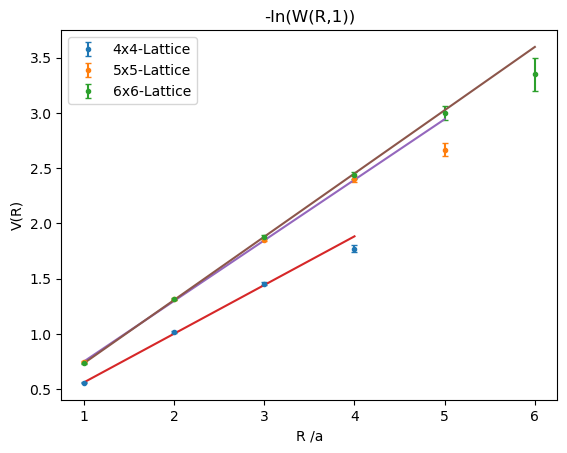

In [25]:
T = 1
R_4,pot_4,pot_4_err = fn.W(data,4,T)
R_5,pot_5,pot_5_err = fn.W(data_5_L,5,T)
R_6,pot_6,pot_6_err = fn.W(data_6_L,6,T)
y_1 = -1*np.log(pot_4)
y_2 = -1*np.log(pot_5)
y_3 = -1*np.log(pot_6)

y_1_err = np.abs(pot_4_err/pot_4)
y_2_err = np.abs(pot_5_err/pot_5)
y_3_err = np.abs(pot_6_err/pot_6)
plt.errorbar(R_4, y_1, yerr= y_1_err,fmt=".",capsize=2, label="4x4-Lattice")
plt.errorbar(R_5, y_2, yerr= y_2_err,fmt=".",capsize=2, label="5x5-Lattice")
plt.errorbar(R_6, y_3, yerr= y_3_err,fmt=".",capsize=2, label="6x6-Lattice")

pram, pram_err = optimize.curve_fit(fn.linear_function,R_4, y_1, sigma=y_1_err)
R_4_p = np.linspace(1,4,1000)
plt.plot(R_4_p, fn.linear_function(R_4_p, *pram))

pram, pram_err = optimize.curve_fit(fn.linear_function,R_5, y_2, sigma=y_2_err)
R_5_p = np.linspace(1,5,1000)
plt.plot(R_5_p, fn.linear_function(R_5_p,*pram))

pram, pram_err = optimize.curve_fit(fn.linear_function,R_6, y_3, sigma=y_3_err)
R_6_p = np.linspace(1,6,1000)
plt.plot(R_6_p, fn.linear_function(R_6_p,*pram))


plt.title("-ln(W(R,1))")
plt.xlabel("R /a")
plt.ylabel("V(R)")
plt.legend()
plt.savefig(save_path+"pot_V_T_1.png")
plt.show()

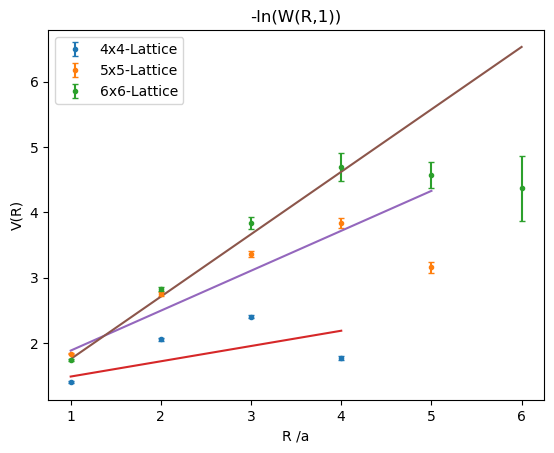

In [26]:
T = 3
R_4,pot_4,pot_4_err = fn.W(data,4,T)
R_5,pot_5,pot_5_err = fn.W(data_5_L,5,T)
R_6,pot_6,pot_6_err = fn.W(data_6_L,6,T)
y_1 = -1*np.log(pot_4)
y_2 = -1*np.log(pot_5)
y_3 = -1*np.log(pot_6)

y_1_err = np.abs(pot_4_err/pot_4)
y_2_err = np.abs(pot_5_err/pot_5)
y_3_err = np.abs(pot_6_err/pot_6)
plt.errorbar(R_4, y_1, yerr= y_1_err,fmt=".",capsize=2, label="4x4-Lattice")
plt.errorbar(R_5, y_2, yerr= y_2_err,fmt=".",capsize=2, label="5x5-Lattice")
plt.errorbar(R_6, y_3, yerr= y_3_err,fmt=".",capsize=2, label="6x6-Lattice")

pram, pram_err = optimize.curve_fit(fn.linear_function,R_4, y_1, sigma=y_1_err)
R_4_p = np.linspace(1,4,1000)
plt.plot(R_4_p, fn.linear_function(R_4_p, *pram))

pram, pram_err = optimize.curve_fit(fn.linear_function,R_5, y_2, sigma=y_2_err)
R_5_p = np.linspace(1,5,1000)
plt.plot(R_5_p, fn.linear_function(R_5_p,*pram))

pram, pram_err = optimize.curve_fit(fn.linear_function,R_6, y_3, sigma=y_3_err)
R_6_p = np.linspace(1,6,1000)
plt.plot(R_6_p, fn.linear_function(R_6_p,*pram))


plt.title("-ln(W(R,1))")
plt.xlabel("R /a")
plt.ylabel("V(R)")
plt.legend()
plt.savefig(save_path+"pot_V_T_3.png")
plt.show()

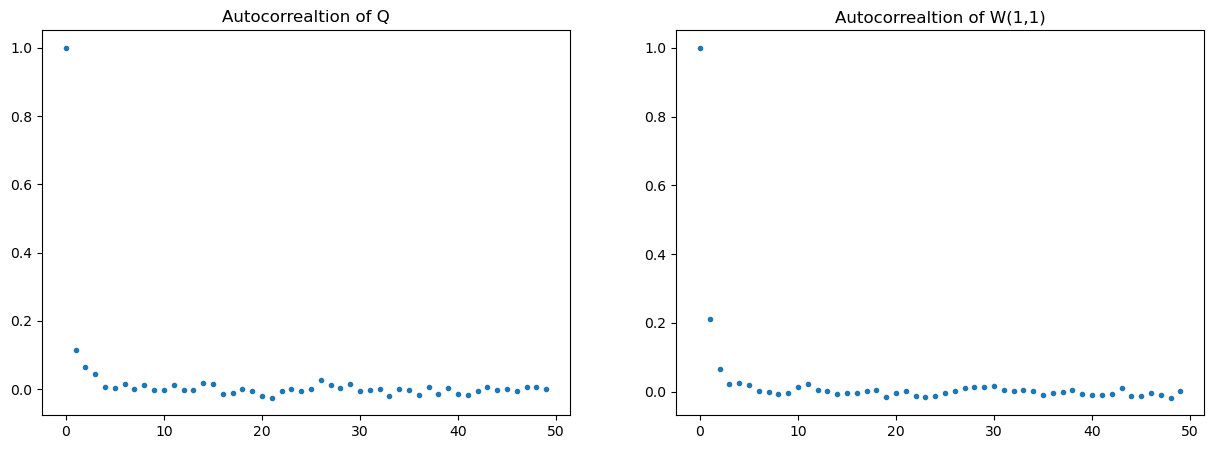

In [27]:

auto_corr_pot = fn.autocorr_array(W_5[:,0],50)
auto_corr_Q = fn.autocorr_array(T_Q_5_L,50)


fig,ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(auto_corr_Q,".")
ax[0].set_title("Autocorrealtion of Q")

ax[1].plot(auto_corr_pot,".")
ax[1].set_title("Autocorrealtion of W(1,1)")
plt.savefig(save_path+"autocorr_5_Lattice.png")
plt.show()